# 04 — Evaluation: Baseline RAG vs Verified RAG

This notebook is the research evaluation layer of **VerifiedRAG**.

We compare:

```text
Baseline:  Question → Retrieve → Generate → Answer

Verified:  Question → Retrieve → Generate → Claims
                              ↓
                         NLI Verification
                              ↓
                         Guardrail/Repair
```

Main metrics:
- claim support rate
- unsupported-claim rate
- refutation rate
- strict answer pass rate
- citation validity
- latency
- repair overhead

**Important:** the initial benchmark is a sanity-check benchmark. Expand and manually validate it before reporting final research results.


## 1. Install dependencies

In [1]:
!pip -q install transformers accelerate bitsandbytes sentence-transformers faiss-cpu pandas numpy tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 63.5 MB/s eta 0:00:00


In [2]:
import os
from pathlib import Path

# Clean direct Git clone URL
REPO_URL = "https://github.com/faizzanasghar/Verified-RAG.git"
TARGET_DIR = "/content/verified-rag"

# 1. Clone repository if not already present
if not os.path.exists(TARGET_DIR):
    !git clone {REPO_URL} {TARGET_DIR}
else:
    print(f"{TARGET_DIR} already exists.")

# 2. Check if vector index and metadata exist; if missing, execute data preparation
required_files = [
    Path(TARGET_DIR) / "data/processed/corpus_metadata.json",
    Path(TARGET_DIR) / "data/processed/papers.json",
    Path(TARGET_DIR) / "data/vector_store/faiss.index",
    Path(TARGET_DIR) / "data/vector_store/chunks_metadata.json",
]

if any(not p.exists() for p in required_files):
    print("Corpus artifacts or FAISS index missing. Executing 01_data_preparation.ipynb via nbconvert...")
    !jupyter nbconvert --to notebook --execute {TARGET_DIR}/notebooks/01_data_preparation.ipynb --output /tmp/data_prep_out.ipynb
    print("Corpus and vector store built successfully.")
else:
    print("All required data artifacts and FAISS index are ready.")

Cloning into '/content/verified-rag'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 42 (delta 14), reused 28 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 978.58 KiB | 20.82 MiB/s, done.
Resolving deltas: 100% (14/14), done.
All required data artifacts and FAISS index are ready.


## 2. Imports and project paths

In [3]:
from pathlib import Path
import json
import re
import time
import random

import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
)

PROJECT_ROOT = Path("/content/verified-rag")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VECTOR_DIR = PROJECT_ROOT / "data" / "vector_store"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Project:", PROJECT_ROOT)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Project: /content/verified-rag
CUDA: True
GPU: Tesla T4


## 3. Load the corpus and FAISS index

In [4]:
required = [
    PROCESSED_DIR / "corpus_metadata.json",
    PROCESSED_DIR / "papers.json",
    VECTOR_DIR / "faiss.index",
    VECTOR_DIR / "chunks_metadata.json",
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Run 01_data_preparation.ipynb first. Missing:\n" + "\n".join(missing)
    )

with (PROCESSED_DIR / "corpus_metadata.json").open(encoding="utf-8") as f:
    corpus_metadata = json.load(f)

with (PROCESSED_DIR / "papers.json").open(encoding="utf-8") as f:
    papers = json.load(f)

with (VECTOR_DIR / "chunks_metadata.json").open(encoding="utf-8") as f:
    chunks_metadata = json.load(f)

faiss_index = faiss.read_index(str(VECTOR_DIR / "faiss.index"))

print("Papers:", len(papers))
print("Chunks:", len(chunks_metadata))
print("FAISS vectors:", faiss_index.ntotal)


Papers: 5
Chunks: 516
FAISS vectors: 516


## 4. Retrieval

In [5]:
EMBEDDING_MODEL_NAME = corpus_metadata.get(
    "embedding_model",
    "sentence-transformers/all-MiniLM-L6-v2"
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

def retrieve(query, top_k=5):
    vector = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = faiss_index.search(vector, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        item = chunks_metadata[int(idx)].copy()
        item["score"] = float(score)
        results.append(item)
    return results

print("Embedding model:", EMBEDDING_MODEL_NAME)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2


## 5. Load the fixed generator

In [6]:
GENERATOR_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    GENERATOR_MODEL_NAME,
    trust_remote_code=True
)

if torch.cuda.is_available():
    q_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    generator = AutoModelForCausalLM.from_pretrained(
        GENERATOR_MODEL_NAME,
        quantization_config=q_config,
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True,
    )
else:
    generator = AutoModelForCausalLM.from_pretrained(
        GENERATOR_MODEL_NAME,
        device_map="auto",
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

generator.eval()
print("Generator:", GENERATOR_MODEL_NAME)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generator: Qwen/Qwen2.5-3B-Instruct


## 6. Load the independent NLI verifier

In [7]:
NLI_MODEL_NAME = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"

nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME)

nli_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
nli_model.to(nli_device)
nli_model.eval()

print("Verifier:", NLI_MODEL_NAME)
print("Labels:", nli_model.config.id2label)


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  369MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Verifier: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Labels: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}


## 7. Evaluation benchmark

Each question has lightweight gold keywords for a retrieval sanity check.

For publication-quality evaluation, replace these with manually verified gold evidence chunk IDs.


In [8]:
BENCHMARK = [
    {"id": "q01", "question": "What problem does residual learning address in very deep neural networks?",
     "gold_keywords": ["degradation", "deep", "residual", "optimization"]},
    {"id": "q02", "question": "What is the main architectural idea of the Transformer?",
     "gold_keywords": ["attention", "self-attention", "encoder", "decoder"]},
    {"id": "q03", "question": "Why does the Transformer not require recurrence to model relationships between tokens?",
     "gold_keywords": ["attention", "self-attention", "recurrence"]},
    {"id": "q04", "question": "What is the purpose of pre-training in BERT?",
     "gold_keywords": ["pre-training", "language", "bidirectional", "representation"]},
    {"id": "q05", "question": "What are the two moment estimates used by Adam?",
     "gold_keywords": ["first moment", "second moment", "gradient", "squared"]},
    {"id": "q06", "question": "How does Adam adapt the learning rate for individual parameters?",
     "gold_keywords": ["moment", "learning rate", "gradient", "second moment"]},
]

display(pd.DataFrame(BENCHMARK))


,id,question,gold_keywords
0,q01,What problem does residual learning address in...,"[degradation, deep, residual, optimization]"
1,q02,What is the main architectural idea of the Tra...,"[attention, self-attention, encoder, decoder]"
2,q03,Why does the Transformer not require recurrenc...,"[attention, self-attention, recurrence]"
3,q04,What is the purpose of pre-training in BERT?,"[pre-training, language, bidirectional, repres..."
4,q05,What are the two moment estimates used by Adam?,"[first moment, second moment, gradient, squared]"
5,q06,How does Adam adapt the learning rate for indi...,"[moment, learning rate, gradient, second moment]"


## 8. Retrieval sanity evaluation

In [9]:
def retrieval_keyword_hit(results, keywords):
    text = " ".join(x["text"].lower() for x in results)
    matched = [k for k in keywords if k.lower() in text]
    return {
        "keyword_recall": len(matched) / len(keywords) if keywords else 0,
        "hit": bool(matched),
        "matched": matched,
    }

retrieval_rows = []
for item in BENCHMARK:
    results = retrieve(item["question"], top_k=5)
    score = retrieval_keyword_hit(results, item["gold_keywords"])
    retrieval_rows.append({
        "id": item["id"],
        "keyword_recall@5": score["keyword_recall"],
        "evidence_hit@5": score["hit"],
        "top_similarity": results[0]["score"] if results else 0,
    })

retrieval_df = pd.DataFrame(retrieval_rows)
display(retrieval_df)
print("Mean keyword recall@5:",
      round(retrieval_df["keyword_recall@5"].mean() * 100, 2), "%")


,id,keyword_recall@5,evidence_hit@5,top_similarity
0,q01,1.00,True,0.675684
1,q02,1.00,True,0.439800
2,q03,1.00,True,0.542824
3,q04,0.75,True,0.646537
4,q05,0.75,True,0.697927
5,q06,0.75,True,0.637365


Mean keyword recall@5: 87.5 %


## 9. Common generation utility

In [10]:
SYSTEM_PROMPT = """You are a technical research assistant.

Answer using ONLY the supplied evidence.
Every factual claim must use [SOURCE: chunk_id].
Do not invent facts or source IDs.
If evidence is insufficient, say so.
"""

def generate_text(messages, max_new_tokens=350):
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=8192
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(generator.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = generator.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    n_input = inputs["input_ids"].shape[1]
    return tokenizer.decode(
        outputs[0][n_input:],
        skip_special_tokens=True
    ).strip()


## 10. Baseline RAG

In [11]:
def run_baseline(question, top_k=5):
    start = time.perf_counter()

    retrieved = retrieve(question, top_k=top_k)
    context = "\n\n".join(
        f"[SOURCE: {x['chunk_id']}]\n{x['text']}"
        for x in retrieved
    )

    answer = generate_text([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content":
            f"Question:\n{question}\n\n"
            f"Evidence:\n{context}\n\n"
            "Answer the question."
        }
    ])

    return {
        "question": question,
        "retrieved_chunks": retrieved,
        "answer": answer,
        "latency": time.perf_counter() - start,
    }


## 11. Claim extraction

In [12]:
CLAIM_PROMPT = """Extract atomic factual claims from the answer.

Return ONLY a numbered list.
Each item must contain one independently verifiable factual claim.
Do not include citations or explanations.

ANSWER:
{answer}
"""

def parse_claims(text):
    claims = []
    for line in text.splitlines():
        line = line.strip()
        match = re.match(
            r"^(?:\d+[\).\:\-]|\-|\*)\s*(.+)$",
            line
        )
        if match and match.group(1).strip():
            claims.append(match.group(1).strip())
    return claims

def extract_claims(answer):
    output = generate_text([
        {"role": "system", "content": "Extract atomic factual claims."},
        {"role": "user", "content": CLAIM_PROMPT.format(answer=answer)}
    ], max_new_tokens=250)

    claims = parse_claims(output)
    return claims if claims else ([answer.strip()] if answer.strip() else [])


## 12. Independent NLI verification

In [13]:
def nli_predict(claim, evidence):
    inputs = nli_tokenizer(
        evidence,
        claim,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    inputs = {k: v.to(nli_device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = nli_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)[0]
    scores = {}

    for i, p in enumerate(probs):
        label = nli_model.config.id2label[i].lower()
        if "entail" in label:
            scores["entailment"] = float(p)
        elif "contrad" in label:
            scores["contradiction"] = float(p)
        elif "neutral" in label:
            scores["neutral"] = float(p)

    return scores


def verify_claim(claim, top_k=3):
    evidence = retrieve(claim, top_k=top_k)
    pairs = []

    for item in evidence:
        pairs.append({
            "chunk_id": item["chunk_id"],
            "text": item["text"],
            "retrieval_score": item["score"],
            "nli": nli_predict(claim, item["text"])
        })

    if not pairs:
        return {
            "label": "NOT_ENOUGH_EVIDENCE",
            "entailment": 0.0,
            "contradiction": 0.0,
            "neutral": 1.0,
            "evidence": []
        }

    ent = max(x["nli"]["entailment"] for x in pairs)
    con = max(x["nli"]["contradiction"] for x in pairs)
    neu = max(x["nli"]["neutral"] for x in pairs)

    if con >= 0.80 and con > ent:
        label = "REFUTED"
    elif ent >= 0.70:
        label = "SUPPORTED"
    else:
        label = "NOT_ENOUGH_EVIDENCE"

    return {
        "label": label,
        "entailment": ent,
        "contradiction": con,
        "neutral": neu,
        "evidence": pairs
    }


def evaluate_answer(answer):
    claims = extract_claims(answer)
    verification = []

    for i, claim in enumerate(claims):
        verification.append({
            "claim_id": f"claim_{i+1}",
            "claim": claim,
            **verify_claim(claim)
        })

    labels = [x["label"] for x in verification]
    total = len(labels)
    supported = labels.count("SUPPORTED")
    refuted = labels.count("REFUTED")
    insufficient = labels.count("NOT_ENOUGH_EVIDENCE")

    return {
        "claims": verification,
        "num_claims": total,
        "support_rate": supported / total if total else 0,
        "refutation_rate": refuted / total if total else 0,
        "unsupported_rate": insufficient / total if total else 0,
        "strict_pass": total > 0 and supported == total,
    }


## 13. Run baseline evaluation

In [14]:
baseline_results = []

for item in tqdm(BENCHMARK, desc="Baseline RAG"):
    output = run_baseline(item["question"], top_k=5)
    factuality = evaluate_answer(output["answer"])
    baseline_results.append({**output, **factuality})

print("Evaluated:", len(baseline_results))


Baseline RAG:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluated: 6


## 14. Verified RAG with bounded repair

In [15]:
REPAIR_PROMPT = """Rewrite the draft using ONLY claims labeled SUPPORTED.

Remove REFUTED and NOT_ENOUGH_EVIDENCE claims.
Do not introduce new facts.
Use only the verified source IDs.
Every factual claim must cite [SOURCE: chunk_id].
Return only the final answer.
"""

def run_verified(question, top_k=5, claim_top_k=3, max_repairs=2):
    start = time.perf_counter()

    retrieved = retrieve(question, top_k=top_k)
    context = "\n\n".join(
        f"[SOURCE: {x['chunk_id']}]\n{x['text']}"
        for x in retrieved
    )

    answer = generate_text([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content":
            f"Question:\n{question}\n\n"
            f"Evidence:\n{context}\n\n"
            "Answer the question."
        }
    ])

    repairs = 0

    while True:
        claims = extract_claims(answer)
        verification = [
            {
                "claim_id": f"claim_{i+1}",
                "claim": claim,
                **verify_claim(claim, top_k=claim_top_k)
            }
            for i, claim in enumerate(claims)
        ]

        labels = [x["label"] for x in verification]
        passed = bool(labels) and all(x == "SUPPORTED" for x in labels)

        if passed or repairs >= max_repairs:
            break

        supported = [x for x in verification if x["label"] == "SUPPORTED"]

        evidence = []
        for item in supported:
            for e in item["evidence"]:
                if e["nli"]["entailment"] >= 0.70:
                    evidence.append(
                        f"[SOURCE: {e['chunk_id']}]\n{e['text']}"
                    )

        summary = "\n".join(
            f"{x['claim_id']}: {x['label']} — {x['claim']}"
            for x in verification
        )

        answer = generate_text([
            {"role": "system", "content": REPAIR_PROMPT},
            {"role": "user", "content":
                f"Question:\n{question}\n\n"
                f"Draft:\n{answer}\n\n"
                f"Verification:\n{summary}\n\n"
                f"Verified evidence:\n{chr(10).join(evidence)}"
            }
        ])

        repairs += 1

    labels = [x["label"] for x in verification]
    total = len(labels)
    supported = labels.count("SUPPORTED")
    refuted = labels.count("REFUTED")
    insufficient = labels.count("NOT_ENOUGH_EVIDENCE")

    return {
        "question": question,
        "retrieved_chunks": retrieved,
        "answer": answer,
        "claims": verification,
        "num_claims": total,
        "support_rate": supported / total if total else 0,
        "refutation_rate": refuted / total if total else 0,
        "unsupported_rate": insufficient / total if total else 0,
        "strict_pass": total > 0 and supported == total,
        "repairs": repairs,
        "latency": time.perf_counter() - start,
    }


## 15. Run verified-RAG evaluation

In [16]:
verified_results = []

for item in tqdm(BENCHMARK, desc="Verified RAG"):
    verified_results.append(
        run_verified(
            item["question"],
            top_k=5,
            claim_top_k=3,
            max_repairs=2
        )
    )

print("Evaluated:", len(verified_results))


Verified RAG:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluated: 6


## 16. Citation validity

In [17]:
SOURCE_PATTERN = re.compile(
    r"\[SOURCE:\s*([^\]]+)\]",
    flags=re.IGNORECASE
)

def citation_metrics(answer, retrieved):
    cited = [x.strip() for x in SOURCE_PATTERN.findall(answer)]
    valid_ids = {x["chunk_id"] for x in retrieved}
    valid = [x for x in cited if x in valid_ids]

    return {
        "citation_count": len(cited),
        "valid_citation_count": len(valid),
        "invalid_citation_count": len(cited) - len(valid),
        "citation_validity": len(valid) / len(cited) if cited else 0,
    }


## 17. Build the comparison table

In [18]:
baseline_rows = []
verified_rows = []

for i, item in enumerate(BENCHMARK):
    b = baseline_results[i]
    v = verified_results[i]

    bc = citation_metrics(b["answer"], b["retrieved_chunks"])
    vc = citation_metrics(v["answer"], v["retrieved_chunks"])

    baseline_rows.append({
        "id": item["id"],
        "support_rate": b["support_rate"],
        "unsupported_rate": b["unsupported_rate"],
        "refutation_rate": b["refutation_rate"],
        "strict_pass": b["strict_pass"],
        "citation_validity": bc["citation_validity"],
        "latency_seconds": b["latency"],
    })

    verified_rows.append({
        "id": item["id"],
        "support_rate": v["support_rate"],
        "unsupported_rate": v["unsupported_rate"],
        "refutation_rate": v["refutation_rate"],
        "strict_pass": v["strict_pass"],
        "citation_validity": vc["citation_validity"],
        "latency_seconds": v["latency"],
        "repairs": v["repairs"],
    })

baseline_df = pd.DataFrame(baseline_rows)
verified_df = pd.DataFrame(verified_rows)

summary_df = pd.DataFrame([
    {
        "system": "Baseline RAG",
        "support_rate": baseline_df["support_rate"].mean(),
        "unsupported_rate": baseline_df["unsupported_rate"].mean(),
        "refutation_rate": baseline_df["refutation_rate"].mean(),
        "strict_pass_rate": baseline_df["strict_pass"].mean(),
        "citation_validity": baseline_df["citation_validity"].mean(),
        "mean_latency_seconds": baseline_df["latency_seconds"].mean(),
        "mean_repairs": 0,
    },
    {
        "system": "Verified RAG",
        "support_rate": verified_df["support_rate"].mean(),
        "unsupported_rate": verified_df["unsupported_rate"].mean(),
        "refutation_rate": verified_df["refutation_rate"].mean(),
        "strict_pass_rate": verified_df["strict_pass"].mean(),
        "citation_validity": verified_df["citation_validity"].mean(),
        "mean_latency_seconds": verified_df["latency_seconds"].mean(),
        "mean_repairs": verified_df["repairs"].mean(),
    }
])

display(summary_df)


,system,support_rate,unsupported_rate,refutation_rate,strict_pass_rate,citation_validity,mean_latency_seconds,mean_repairs
0,Baseline RAG,0.740476,0.217857,0.041667,0.500000,0.166667,7.555883,0.0
1,Verified RAG,0.815476,0.184524,0.000000,0.666667,0.333333,37.566344,1.0


## 18. Improvement and latency overhead

In [19]:
b = summary_df.iloc[0]
v = summary_df.iloc[1]

comparison = pd.DataFrame({
    "metric": [
        "Support-rate improvement",
        "Unsupported-rate reduction",
        "Refutation-rate reduction",
        "Strict-pass improvement",
        "Citation-validity improvement",
        "Latency overhead",
    ],
    "difference": [
        v["support_rate"] - b["support_rate"],
        b["unsupported_rate"] - v["unsupported_rate"],
        b["refutation_rate"] - v["refutation_rate"],
        v["strict_pass_rate"] - b["strict_pass_rate"],
        v["citation_validity"] - b["citation_validity"],
        (
            (v["mean_latency_seconds"] - b["mean_latency_seconds"])
            / b["mean_latency_seconds"]
            if b["mean_latency_seconds"] else 0
        ),
    ]
})

display(comparison)


,metric,difference
0,Support-rate improvement,0.075000
1,Unsupported-rate reduction,0.033333
2,Refutation-rate reduction,0.041667
3,Strict-pass improvement,0.166667
4,Citation-validity improvement,0.166667
5,Latency overhead,3.971801


## 19. Per-question comparison

In [20]:
per_question = pd.DataFrame({
    "id": [x["id"] for x in BENCHMARK],
    "baseline_support": baseline_df["support_rate"],
    "verified_support": verified_df["support_rate"],
    "support_delta": verified_df["support_rate"] - baseline_df["support_rate"],
    "baseline_unsupported": baseline_df["unsupported_rate"],
    "verified_unsupported": verified_df["unsupported_rate"],
    "baseline_refuted": baseline_df["refutation_rate"],
    "verified_refuted": verified_df["refutation_rate"],
    "baseline_pass": baseline_df["strict_pass"],
    "verified_pass": verified_df["strict_pass"],
    "repairs": verified_df["repairs"],
})

display(per_question)


,id,baseline_support,verified_support,support_delta,baseline_unsupported,verified_unsupported,baseline_refuted,verified_refuted,baseline_pass,verified_pass,repairs
0,q01,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0
1,q02,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0
2,q03,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0
3,q04,0.500000,0.750000,0.25,0.250000,0.250000,0.25,0.0,False,False,2
4,q05,0.800000,1.000000,0.20,0.200000,0.000000,0.00,0.0,False,True,2
5,q06,0.142857,0.142857,0.00,0.857143,0.857143,0.00,0.0,False,False,2


## 20. Plot claim support rate

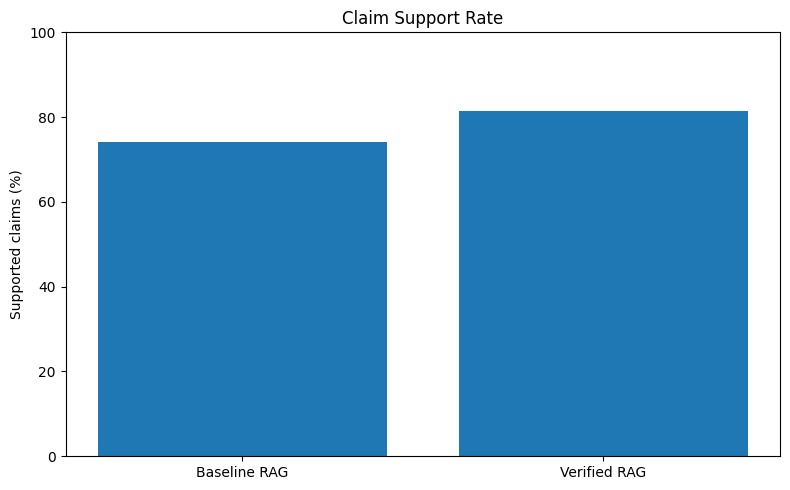

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["system"], summary_df["support_rate"] * 100)
plt.ylabel("Supported claims (%)")
plt.title("Claim Support Rate")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


## 21. Plot unsupported and refuted claims

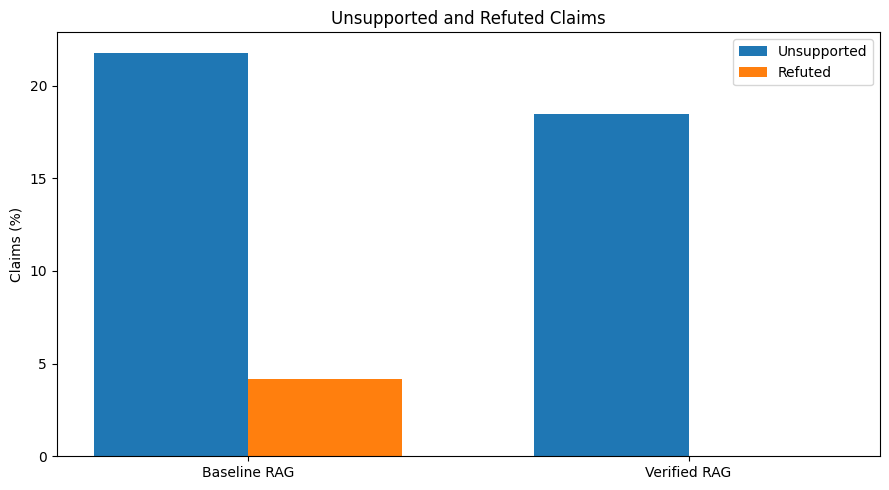

In [22]:
x = np.arange(2)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(
    x - width / 2,
    summary_df["unsupported_rate"] * 100,
    width,
    label="Unsupported"
)
plt.bar(
    x + width / 2,
    summary_df["refutation_rate"] * 100,
    width,
    label="Refuted"
)
plt.xticks(x, summary_df["system"])
plt.ylabel("Claims (%)")
plt.title("Unsupported and Refuted Claims")
plt.legend()
plt.tight_layout()
plt.show()


## 22. Plot latency overhead

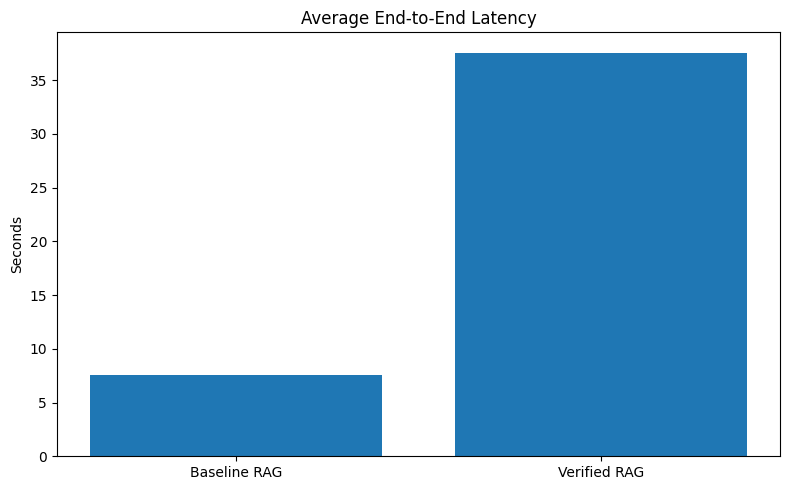

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["system"], summary_df["mean_latency_seconds"])
plt.ylabel("Seconds")
plt.title("Average End-to-End Latency")
plt.tight_layout()
plt.show()


## 23. Failure-case analysis

Inspect:
- baseline fails but verified succeeds
- both systems fail
- verified RAG rejects a potentially correct answer
- verification adds latency without improving factuality

These cases are valuable for the limitations section of the research report.


In [24]:
failure_table = per_question.copy()

failure_table["verified_improved"] = (
    (~failure_table["baseline_pass"]) &
    (failure_table["verified_pass"])
)

failure_table["both_failed"] = (
    (~failure_table["baseline_pass"]) &
    (~failure_table["verified_pass"])
)

display(failure_table)


,id,baseline_support,verified_support,support_delta,baseline_unsupported,verified_unsupported,baseline_refuted,verified_refuted,baseline_pass,verified_pass,repairs,verified_improved,both_failed
0,q01,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0,False,False
1,q02,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0,False,False
2,q03,1.000000,1.000000,0.00,0.000000,0.000000,0.00,0.0,True,True,0,False,False
3,q04,0.500000,0.750000,0.25,0.250000,0.250000,0.25,0.0,False,False,2,False,True
4,q05,0.800000,1.000000,0.20,0.200000,0.000000,0.00,0.0,False,True,2,True,False
5,q06,0.142857,0.142857,0.00,0.857143,0.857143,0.00,0.0,False,False,2,False,True


## 24. Inspect one complete verified example

In [25]:
QUESTION_INDEX = 0
selected = verified_results[QUESTION_INDEX]

print("QUESTION:\n", selected["question"])
print("\nFINAL ANSWER:\n", selected["answer"])

for claim in selected["claims"]:
    print("\n" + "=" * 100)
    print(claim["claim_id"], "|", claim["label"])
    print(claim["claim"])

    for evidence in claim["evidence"]:
        print("-" * 80)
        print(
            "Source:", evidence["chunk_id"],
            "| entailment:", round(evidence["nli"]["entailment"], 3),
            "| contradiction:", round(evidence["nli"]["contradiction"], 3)
        )
        print(evidence["text"][:1200])


QUESTION:
 What problem does residual learning address in very deep neural networks?

FINAL ANSWER:
 Residual learning addresses the problem of vanishing and exploding gradients in very deep neural networks, which makes training difficult. As the network becomes deeper, residual learning enables the network to start converging for stochastic gradient descent (SGD) with backpropagation. However, with increasing depth, residual learning exposes a degradation problem where accuracy initially saturates and then degrades rapidly, not due to overfitting.

claim_1 | SUPPORTED
Residual learning addresses the problem of vanishing and exploding gradients in very deep neural networks, which makes training difficult. As the network becomes deeper, residual learning enables the network to start converging for stochastic gradient descent (SGD) with backpropagation. However, with increasing depth, residual learning exposes a degradation problem where accuracy initially saturates and then degrades rap

## 25. Paired bootstrap confidence interval

The unit of resampling is the **question**, not the individual claim, because claims within one answer are not independent.

Use this again after expanding the benchmark.


In [26]:
def bootstrap_difference(
    baseline_values,
    verified_values,
    n_boot=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    b = np.asarray(baseline_values, dtype=float)
    v = np.asarray(verified_values, dtype=float)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(b), len(b))
        diffs.append(v[idx].mean() - b[idx].mean())

    diffs = np.asarray(diffs)

    return {
        "observed": v.mean() - b.mean(),
        "ci_lower": np.percentile(diffs, 2.5),
        "ci_upper": np.percentile(diffs, 97.5),
    }

support_bootstrap = bootstrap_difference(
    baseline_df["support_rate"],
    verified_df["support_rate"]
)

print("Observed difference:",
      round(support_bootstrap["observed"], 4))
print(
    "95% bootstrap CI:",
    round(support_bootstrap["ci_lower"], 4),
    "to",
    round(support_bootstrap["ci_upper"], 4)
)


Observed difference: 0.075
95% bootstrap CI: 0.0 to 0.1583


## 26. Save evaluation artifacts

In [27]:
baseline_path = RESULTS_DIR / "baseline_evaluation.csv"
verified_path = RESULTS_DIR / "verified_evaluation.csv"
summary_path = RESULTS_DIR / "evaluation_summary.csv"
comparison_path = RESULTS_DIR / "evaluation_comparison.csv"
json_path = RESULTS_DIR / "evaluation_results.json"

baseline_df.to_csv(baseline_path, index=False)
verified_df.to_csv(verified_path, index=False)
summary_df.to_csv(summary_path, index=False)
comparison.to_csv(comparison_path, index=False)

payload = {
    "metadata": {
        "seed": SEED,
        "generator_model": GENERATOR_MODEL_NAME,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "nli_model": NLI_MODEL_NAME,
        "top_k": 5,
        "claim_top_k": 3,
        "max_repairs": 2,
        "benchmark_size": len(BENCHMARK),
    },
    "summary": summary_df.to_dict(orient="records"),
    "comparison": comparison.to_dict(orient="records"),
    "per_question": per_question.to_dict(orient="records"),
    "bootstrap_support": support_bootstrap,
}

with json_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
for p in [baseline_path, verified_path, summary_path, comparison_path, json_path]:
    print(" -", p)


Saved:
 - /content/verified-rag/results/baseline_evaluation.csv
 - /content/verified-rag/results/verified_evaluation.csv
 - /content/verified-rag/results/evaluation_summary.csv
 - /content/verified-rag/results/evaluation_comparison.csv
 - /content/verified-rag/results/evaluation_results.json


# Final research checklist

Before using any number on your resume:

- Run notebooks 01, 02, 03, and 04 successfully.
- Manually validate the benchmark's gold evidence.
- Inspect failure cases.
- Report verifier limitations.
- Keep baseline and verified systems on the same corpus/retriever/generator.
- Do not present the six-question sanity benchmark as a large research study.
- Use only the actual measured numbers.

A final resume bullet can then be written as:

> **Engineered a multi-agent RAG pipeline with claim-level NLI verification and guarded self-repair, reducing unsupported claims by X% versus baseline RAG while maintaining Y% citation validity.**

Replace X and Y only after the experiment produces real measurements.


In [ ]:
import json
from pathlib import Path
from google.colab import _message

# 1. Download current notebook state into notebooks/04_evaluation.ipynb
notebook_json = _message.blocking_request("get_ipynb")
target_nb_path = Path("/content/verified-rag/notebooks/04_evaluation.ipynb")

with open(target_nb_path, "w", encoding="utf-8") as f:
    json.dump(notebook_json["ipynb"], f, indent=2)

print(f"Saved notebook to {target_nb_path}")